### Project Overview :
##### This project focuses on Binary Sentiment Classification, specifically aiming to classify movie reviews as either "positive" (good) or "negative" (bad). The ability to accurately predict sentiment is critical for recommendation systems, market research, and understanding audience engagement.

### Dataset Description :
##### For this study, we utilize the IMDB Large Movie Review Dataset v1.0, introduced by Maas et al. (2011). This dataset is a standard benchmark for binary sentiment classification. It contains a balanced split of 50,000 highly polar movie reviews, divided evenly into 25,000 training and 25,000 testing samples.
##### Ref: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
##### Input: Raw text of movie reviews (varying lengths).

##### Output: A binary label (0 for negative, 1 for positive). The dataset represents a challenging real-world problem as the text is unstructured and contains noise such as HTML tags, punctuation, and colloquialisms.

### Project Objectives :
##### Evaluate the trade-off between model complexity and performance. We will implement and compare two distinct approaches:

##### Custom Architecture (From Scratch): We will build a Deep Neural Network (likely LSTM or CNN) trained entirely on our dataset. This demonstrates the fundamentals of model construction.

##### Transfer Learning (Pretrained): We will fine-tune a model that has been pre-trained on a massive corpus of text (such as GloVe or BERT). By comparing these two, we aim to demonstrate how Transfer Learning can leverage prior knowledge to achieve higher accuracy with potentially less training data, compared to learning from scratch.

In [20]:
### Libararies used ###
import pandas as pd
import re
import random
from nltk.corpus import wordnet
import nltk
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, AveragePooling1D, BatchNormalization, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

## loading dataset ##
# Execute this step.
try:
    df = pd.read_csv('IMDB Dataset.csv')
    print("Data Loaded Successfully!")
except FileNotFoundError:
    print("Error: 'IMDB Dataset.csv' not found. Please upload it.")

Data Loaded Successfully!


In [21]:
# Setting random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

#### Dataset Information

In [22]:

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [23]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


#### Statistical Summary

In [24]:

df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


#### Dataset Dimensions

In [25]:

df.shape

(50000, 2)

#### Check for Missing Values

In [26]:

df.isnull().sum()

review       0
sentiment    0
dtype: int64

#### Remove Duplicates

In [27]:

df.duplicated().sum()   # Before removing duplicates
df.drop_duplicates(keep='first', inplace=True)
df.duplicated().sum()   # After removing duplicates

np.int64(0)

#### Convert Labels to Numeric


In [28]:

df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

#### Calculate Review Length

In [29]:

df['word_count'] = df['review'].apply(lambda x: len(x.split()))

print(df['word_count'].describe())

count    49582.000000
mean       231.350167
std        171.542020
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: word_count, dtype: float64


## Visualization


#### Univariate exploratory analysis was conducted to examine the distribution of review lengths. The histogram shows a right-skewed distribution, indicating that most reviews contain fewer than 300 words, with a small number of very long reviews. The presence of outliers supports the need for sequence truncation when training deep learning models


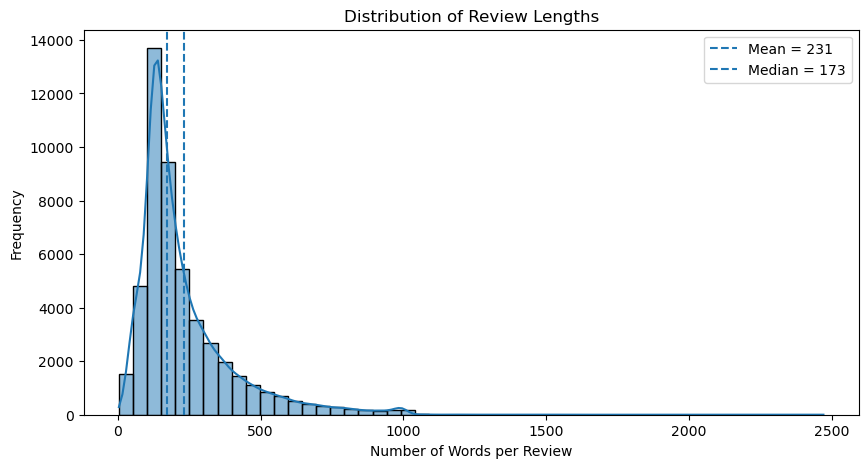

In [30]:

mean_len = df['word_count'].mean()
median_len = df['word_count'].median()

plt.figure(figsize=(10,5))
# Create a seaborn visualization.
sns.histplot(df['word_count'], bins=50, kde=True)
plt.axvline(mean_len, linestyle='--', label=f"Mean = {int(mean_len)}")
plt.axvline(median_len, linestyle='--', label=f"Median = {int(median_len)}")
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words per Review")
plt.ylabel("Frequency")
plt.legend()
plt.show()


#### Bivariate analysis was performed to investigate the relationship between review length and sentiment. The box plot indicates similar median lengths for both positive and negative reviews, with a slightly wider spread for positive reviews. This suggests that review length alone is not a strong discriminator of sentiment.


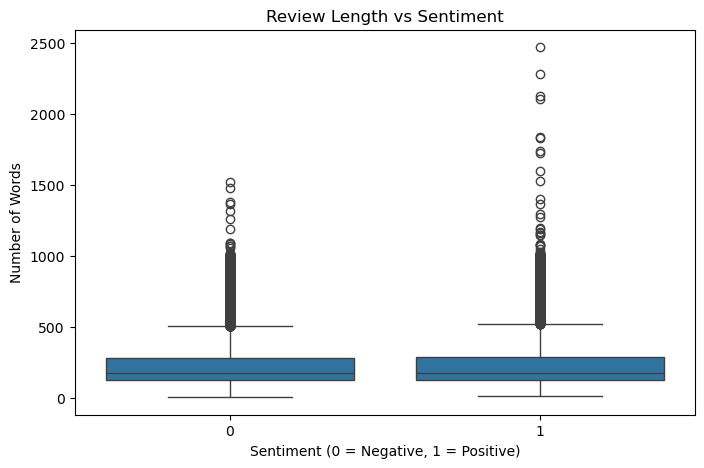

In [31]:

plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='word_count', data=df)
plt.title("Review Length vs Sentiment")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Words")
plt.show()


#### Multivariate exploratory analysis was conducted by examining the interaction between review length, sentiment class, and frequency distribution. The stacked histogram reveals a significant overlap between positive and negative review lengths, indicating that sentiment classification depends more on textual semantics than on review length statistics.


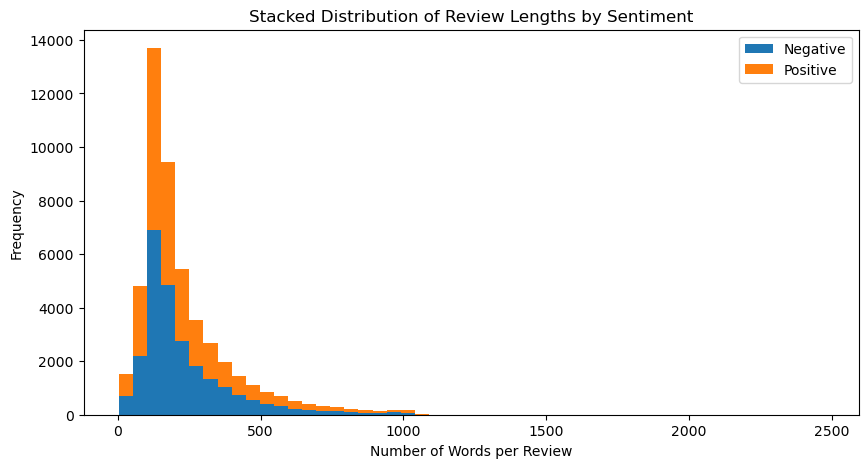

In [32]:

plt.figure(figsize=(10,5))
plt.hist(
    [df[df['sentiment']==0]['word_count'],
     df[df['sentiment']==1]['word_count']],
    bins=50,
    stacked=True,
    label=['Negative', 'Positive']
)
plt.title("Stacked Distribution of Review Lengths by Sentiment")
plt.xlabel("Number of Words per Review")
plt.ylabel("Frequency")
plt.legend()
plt.show()

#### Class Distribution Visualization

##### The plot shows that the dataset is perfectly balanced, with an equal number of positive and negative reviews after duplicate removal. This balanced distribution ensures that the deep learning model will not suffer from class imbalance issues and is suitable for training without requiring sampling or weighting techniques.

C:\Users\Doha\AppData\Local\Temp\ipykernel_17392\3254851769.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


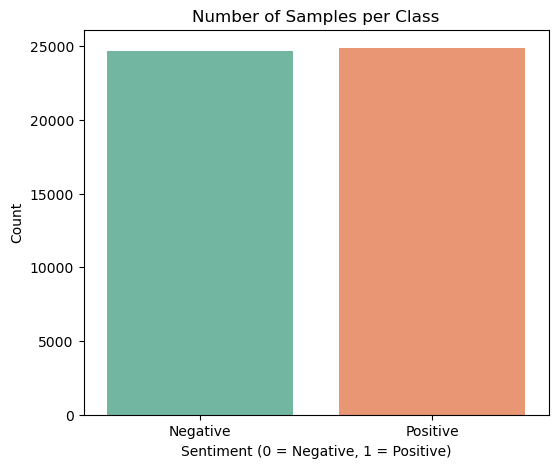

In [33]:

plt.figure(figsize=(6,5))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title("Number of Samples per Class")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.show()


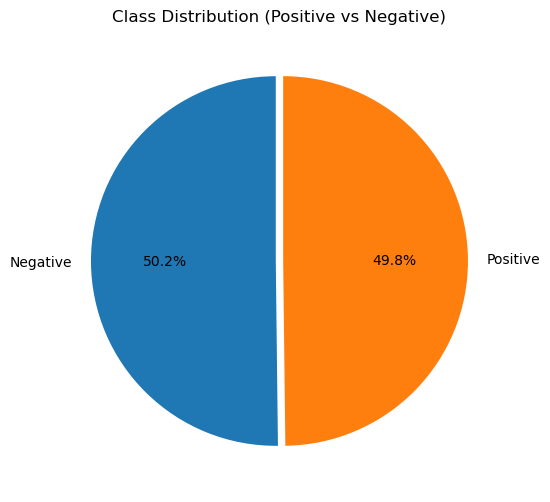

In [34]:
plt.figure(figsize=(6,6))
df['sentiment'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Negative','Positive'],
    startangle=90,
    explode=[0.02, 0.02]
)
plt.ylabel("")
plt.title("Class Distribution (Positive vs Negative)")
plt.show()


## Text preprocessing

In [35]:
# Clean text
def clean_text_minimal(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_review'] = df['review'].apply(clean_text_minimal)


In [36]:
# Split data
X = df['clean_review']

# One-hot labels (2 classes) for the Keras softmax models below
# Class ids: 0 = negative, 1 = positive

y = pd.get_dummies(df['sentiment']).values #binary vectors

# Stratify to preserve label distribution in train/test 
X_train_text, X_test_text, y_train, y_test = train_test_split(
    # The cleaned reviews
    X, 
    # Labels
    y,
    test_size=0.2,
    random_state=42,
    # Keeps the same class distribution in train and test sets
    stratify=df['sentiment']
)

### Data Split + Leakage Prevention (Required)

- **Split strategy**: We split the cleaned reviews into **training (80%)** and **test (20%)** using a fixed `random_state=42` for reproducibility.
- **Validation strategy**: During model training we use `validation_split=0.2`, which holds out **20% of the training data** for validation.
- **Leakage prevention**:
  - The `Tokenizer` is **fit only on the training text** (not test).
  - Data augmentation is applied **only to the training set** (not validation/test).

**Note (NLP vs tabular)**: Standard feature scaling (e.g., StandardScaler) is not applicable to raw text. The NLP equivalent is consistent tokenization, padding/truncation to `max_len`, and using embeddings (random or pretrained).


### Baseline Model : TF‑IDF + Logistic Regression

To show the value of deep learning, we compare against a simple and strong NLP baseline:

- Convert text to TF‑IDF vectors (fit on training only)
- Train Logistic Regression
- Evaluate on the same test set using Accuracy + (bonus) Precision/Recall/F1

This baseline is fast and often performs surprisingly well on sentiment classification.


In [37]:
# Baseline: TF-IDF + Logistic Regression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Convert one-hot labels to class ids for sklearn
# (0 = negative, 1 = positive)
y_train_lbl = y_train.argmax(axis=1)
y_test_lbl = y_test.argmax(axis=1)

# TF-IDF: fit ONLY on training to avoid leakage
# Gives higher weight to important words
#Reduces weight of common words

vectorizer = TfidfVectorizer( 
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

baseline_clf = LogisticRegression(max_iter=2000)
baseline_clf.fit(X_train_tfidf, y_train_lbl)


y_pred_base = baseline_clf.predict(X_test_tfidf)
baseline_test_acc = accuracy_score(y_test_lbl, y_pred_base)

print(f"Baseline (TF-IDF+LR) Test Accuracy: {baseline_test_acc*100:.2f}%").
print(classification_report(y_test_lbl, y_pred_base, target_names=['negative', 'positive']))


Baseline (TF-IDF+LR) Test Accuracy: 90.03%
              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4940
    positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



In [38]:
# Data Augmentation (only on training set)
def synonym_replacement(text, n=2):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set(words))
    random.shuffle(random_word_list)
    num_replaced = 0

    for word in random_word_list:
        synonyms = wordnet.synsets(word)
        if synonyms:
            synonym = synonyms[0].lemmas()[0].name()
            if synonym != word:
                new_words = [synonym if w == word else w for w in new_words]
                num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

def random_deletion(text, p=0.1):
    words = text.split()
    if len(words) == 1:
        return text
    remaining = [word for word in words if random.random() > p]
    if len(remaining) == 0:
        return random.choice(words)
    return ' '.join(remaining)

# Apply augmentation only on training set
aug_train_sr = X_train_text.apply(lambda x: synonym_replacement(x))
aug_train_rd = X_train_text.apply(lambda x: random_deletion(x))

# Combine original + augmented training data
X_train_aug = pd.concat([X_train_text, aug_train_sr, aug_train_rd], ignore_index=True)
y_train_aug = pd.concat([pd.DataFrame(y_train), pd.DataFrame(y_train), pd.DataFrame(y_train)], ignore_index=True)

# Shuffle training data

train_df = pd.concat([X_train_aug, y_train_aug], axis=1)
train_df = train_df.sample(frac=1).reset_index(drop=True)

X_train_aug = train_df.iloc[:,0]
y_train_aug = train_df.iloc[:,1:].values


In [39]:
#Tokenization
vocab_size = 10000
max_len = 100

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train_aug)

X_train_seq = tokenizer.texts_to_sequences(X_train_aug)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)

X_test_seq = tokenizer.texts_to_sequences(X_test_text)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

### Hybrid CNN-BiLSTM Text Classification Model

In [40]:
# Assign a value to `embedding_dim`.
embedding_dim = 100
l2_lambda = 0.0001

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Conv1D(32, 3, activation='relu', kernel_regularizer=l2(l2_lambda)),
    BatchNormalization(),
    AveragePooling1D(2),
    Dropout(0.3),
    Conv1D(64, 3, activation='relu', kernel_regularizer=l2(l2_lambda)),
    BatchNormalization(),
    AveragePooling1D(2),
    Dropout(0.3),
    Conv1D(128, 3, activation='relu', kernel_regularizer=l2(l2_lambda)),
    BatchNormalization(),
    AveragePooling1D(2),
    Dropout(0.3),
     
    Bidirectional(LSTM(64, return_sequences=False,recurrent_dropout=0.2, kernel_regularizer=l2(l2_lambda))),
    Dense(64, activation='relu', kernel_regularizer=l2(l2_lambda)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(l2_lambda)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.build(input_shape=(None, max_len))
model.summary()


c:\Users\Doha\miniconda3\envs\DL\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 98, 32)         │         9,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 49, 32)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 47, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 23, 64)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 21, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_2             │ (None, 10, 128)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            6

 Total params: 1,151,042 (4.39 MB)

 Trainable params: 1,150,402 (4.39 MB)

 Non-trainable params: 640 (2.50 KB)

In [41]:
# Training
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)


history = model.fit(
    X_train_pad, y_train_aug,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.7911 - loss: 0.5008 - val_accuracy: 0.8801 - val_loss: 0.3455 - learning_rate: 0.0010
Epoch 2/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.8965 - loss: 0.3057 - val_accuracy: 0.9017 - val_loss: 0.3120 - learning_rate: 0.0010
Epoch 3/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.9312 - loss: 0.2175 - val_accuracy: 0.9339 - val_loss: 0.2120 - learning_rate: 0.0010
Epoch 4/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9522 - loss: 0.1607 - val_accuracy: 0.9309 - val_loss: 0.2407 - learning_rate: 0.0010
Epoch 5/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9625 - loss: 0.1284 - val_accuracy: 0.9558 - val_loss: 0.1533 - learning_rate: 0.0010
Epoch 6/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9703 - loss: 0.1078 - val_accuracy: 0.9631 - val_loss: 0.1418 - learning_rate: 0.0010
Epoch 7/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accura

In [42]:
# Access metrics
# Assign a value to `train_loss`.
train_loss = history.history['loss']          # training loss per epoch
# Assign a value to `train_acc`.
train_acc = history.history['accuracy']       # training accuracy per epoch
# Assign a value to `val_loss`.
val_loss = history.history['val_loss']       # validation loss per epoch
# Assign a value to `val_acc`.
val_acc = history.history['val_accuracy']    # validation accuracy per epoch

# Example: print last epoch's metrics
# Display output for inspection.
print(f"Final training accuracy: {train_acc[-1]*100:.2f}%")
# Display output for inspection.
print(f"Final validation accuracy: {val_acc[-1]*100:.2f}%")


Final training accuracy: 99.64%
Final validation accuracy: 98.37%


In [43]:
# Evaluate on test data
# Assign a value to `test_loss_scratch, test_acc_scratch`.
test_loss_scratch, test_acc_scratch = model.evaluate(X_test_pad, y_test, verbose=0)
# Display output for inspection.
print(f"Scratch model Test Accuracy: {test_acc_scratch*100:.2f}%")
# Display output for inspection.
print(f"Scratch model Test Loss: {test_loss_scratch:.4f}")


Scratch model Test Accuracy: 84.28%
Scratch model Test Loss: 1.0042


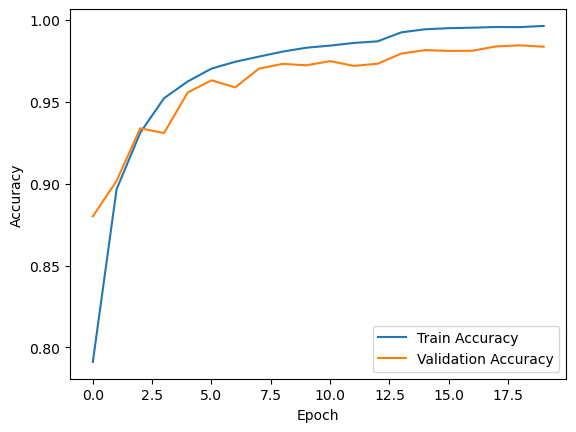

In [44]:

# Create/format a plot.
plt.plot(train_acc, label='Train Accuracy')
# Create/format a plot.
plt.plot(val_acc, label='Validation Accuracy')
# Create/format a plot.
plt.xlabel('Epoch')
# Create/format a plot.
plt.ylabel('Accuracy')
# Create/format a plot.
plt.legend()
# Create/format a plot.
plt.show()



### Pretrained : GloVe

### Load GloVe into a dictionary

In [45]:

embedding_index = {}
path = r"glove.6B.100d.txt"

with open(path, "r", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

print("Loaded vectors:", len(embedding_index))



Loaded vectors: 400000


### Build the Embedding Matrix

In [46]:

embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        vector = embedding_index.get(word)
        if vector is not None:
            embedding_matrix[i] = vector

print("Embedding matrix shape:", embedding_matrix.shape)


Embedding matrix shape: (10000, 100)


### Replace your embedding layer with pretrained GloVe

In [47]:
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_shape=(max_len,), 
    trainable=False
)


c:\Users\Doha\miniconda3\envs\DL\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Full Model 2: CNN-BiLSTM with GloVe (Transfer Learning)

In [48]:

l2_lambda = 0.0001
model_glove = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_shape=(max_len,),
        trainable=False
    ),

    Conv1D(32, 3, activation='relu', kernel_regularizer=l2(l2_lambda)),
    BatchNormalization(),
    AveragePooling1D(2),
    Dropout(0.3),
    Conv1D(64, 3, activation='relu', kernel_regularizer=l2(l2_lambda)),
    BatchNormalization(),
    AveragePooling1D(2),
    Dropout(0.3),
    Conv1D(128, 3, activation='relu', kernel_regularizer=l2(l2_lambda)),
    BatchNormalization(),
    AveragePooling1D(2),
    Dropout(0.3),

    Bidirectional(LSTM(64, return_sequences=False, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')

model_glove.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_glove.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 98, 32)         │         9,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 98, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_3             │ (None, 49, 32)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 47, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 47, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_4             │ (None, 23, 64)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 21, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 21, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_5             │ (None, 10, 128)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,658 (4.39 MB)

 Trainable params: 150,210 (586.76 KB)

 Non-trainable params: 1,000,448 (3.82 MB)

In [49]:

history_glove = model_glove.fit(
    X_train_pad, y_train_aug,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8595 - loss: 0.3425 - val_accuracy: 0.8641 - val_loss: 0.3269 - learning_rate: 6.2500e-05
Epoch 10/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8596 - loss: 0.3427 - val_accuracy: 0.8658 - val_loss: 0.3275 - learning_rate: 6.2500e-05


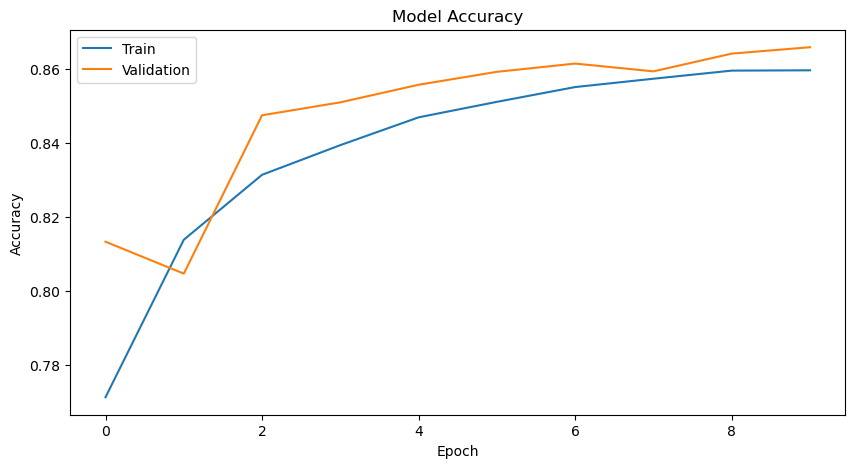

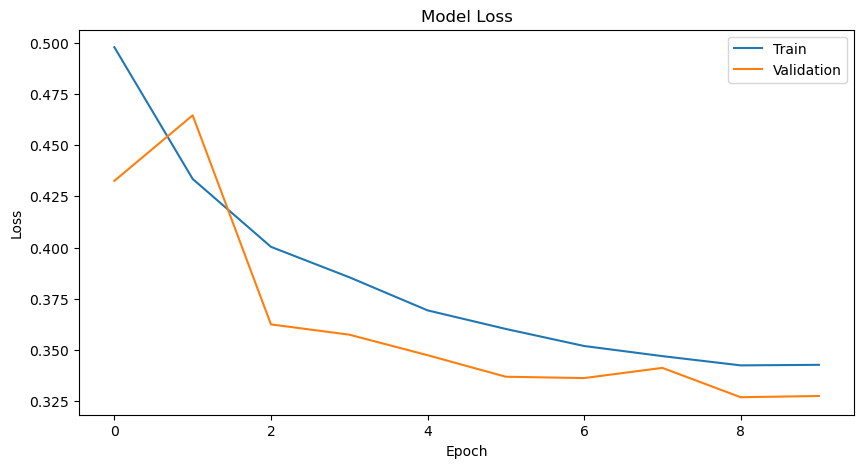

In [50]:
plt.figure(figsize=(10,5))
plt.plot(history_glove.history['accuracy'])
plt.plot(history_glove.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history_glove.history['loss'])
plt.plot(history_glove.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

Overall Analysis
The model is learning effectively:

Both train and validation accuracy increase.

Both losses decrease.

No overfitting yet:

Validation metrics improve in line with training metrics.

ReduceLROnPlateau is working:

Slows learning rate when progress on val_loss slows.

Helps stabilize training.

### Fine Tuning 

In [51]:
# Unfreeze the embedding layer
model_glove.layers[0].trainable = True

# Compile again with a smaller learning rate
from tensorflow.keras.optimizers import Adam
model_glove.compile(
    optimizer=Adam(learning_rate=1e-4),   # smaller LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [52]:

history_finetune = model_glove.fit(
    X_train_pad, y_train_aug,
    epochs=10,               # fewer epochs for fine-tuning
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]


Epoch 1/10
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.8233 - loss: 0.4155 - val_accuracy: 0.8407 - val_loss: 0.3724 - learning_rate: 1.0000e-04
Epoch 2/10
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.8405 - loss: 0.3824 - val_accuracy: 0.8535 - val_loss: 0.3524 - learning_rate: 1.0000e-04
Epoch 3/10
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8543 - loss: 0.3577 - val_accuracy: 0.8605 - val_loss: 0.3392 - learning_rate: 5.0000e-05
Epoch 4/10
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.8603 - loss: 0.3461 - val_accuracy: 0.8662 - val_loss: 0.3292 - learning_rate: 5.0000e-05
Epoch 5/10
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.8661 - loss: 0.3356 - val_accuracy: 0.8688 - val_loss: 0.3238 - learning_rate: 2.5000e-05
Epoch 6/10
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.8687 - loss: 0.3292 - val_accuracy: 0.8694 - val_loss: 0.3210 - learning_rate: 2.5000e-05
Epoch 7/10
1488/1488 ━━━━━━━━━━━━━━━━━━━

In [53]:

train_acc_glove  = history_glove.history['accuracy']
train_loss_glove = history_glove.history['loss']
val_acc_glove    = history_glove.history['val_accuracy']
val_loss_glove   = history_glove.history['val_loss']


In [54]:

test_loss_glove, test_acc_glove = model_glove.evaluate(X_test_pad, y_test)
print(f"GloVe model Test Accuracy: {test_acc_glove*100:.2f}%")
print(f"GloVe model Test Loss: {test_loss_glove:.4f}")


310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8312 - loss: 0.3838
GloVe model Test Accuracy: 83.12%
GloVe model Test Loss: 0.3838


In [55]:
# Model 1: From scratch
metrics_scratch = {
    "train_acc": train_acc[-1],
    "train_loss": train_loss[-1],
    "val_acc": val_acc[-1],
    "val_loss": val_loss[-1],
    "test_acc": test_acc_scratch,
    "test_loss": test_loss_scratch,
}

# Model 2: GloVe pretrained
metrics_glove = {
    "train_acc": train_acc_glove[-1],
    "train_loss": train_loss_glove[-1],
    "val_acc": val_acc_glove[-1],
    "val_loss": val_loss_glove[-1],
    "test_acc": test_acc_glove,
    "test_loss": test_loss_glove,
}


In [56]:

df_metrics = pd.DataFrame([metrics_scratch, metrics_glove], index=['Scratch', 'GloVe'])
df_metrics


,train_acc,train_loss,val_acc,val_loss,test_acc,test_loss
Scratch,0.996376,0.026347,0.983655,0.083422,0.842795,1.004222
GloVe,0.859605,0.342747,0.865835,0.327540,0.831199,0.383793


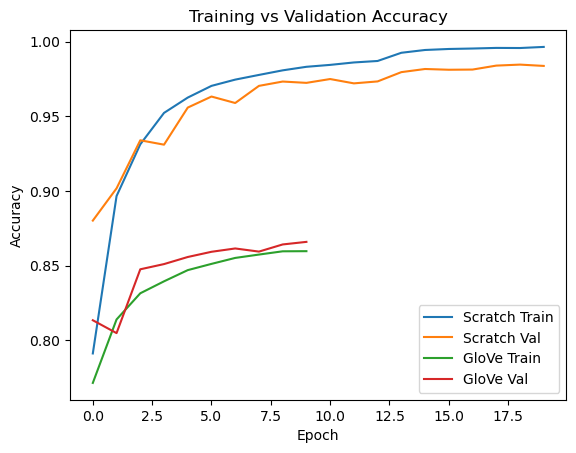

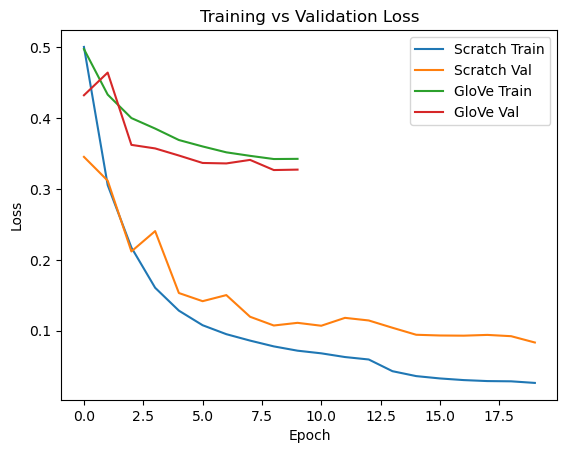

In [ ]:
# Accuracy comparison
plt.plot(train_acc, label='Scratch Train')
plt.plot(val_acc, label='Scratch Val')
plt.plot(train_acc_glove, label='GloVe Train')
plt.plot(val_acc_glove, label='GloVe Val')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss comparison
plt.plot(train_loss, label='Scratch Train')
plt.plot(val_loss, label='Scratch Val')
plt.plot(train_loss_glove, label='GloVe Train')
plt.plot(val_loss_glove, label='GloVe Val')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## Extended Evaluation 

In addition to accuracy/loss, we evaluate:

- *Confusion matrix*
- *Precision / Recall / F1-score*
- *Error analysis*: inspect misclassified reviews

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

# True labels (0 = negative, 1 = positive)
y_true = y_test.argmax(axis=1)

# ---- Model 1 (Scratch) ----
proba_scratch = model.predict(X_test_pad, verbose=0)
y_pred_scratch = proba_scratch.argmax(axis=1)

# ---- Model 2 (GloVe fine-tuned) ----
proba_glove = model_glove.predict(X_test_pad, verbose=0)
y_pred_glove = proba_glove.argmax(axis=1)

# ---- Baseline (TF-IDF + LR) ----
# y_pred_base is created in the baseline cell

def summarize(name, y_pred):
    return {
        'model': name,
        'accuracy': (y_pred == y_true).mean(),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }

summary_df = pd.DataFrame([
    summarize('Baseline TF-IDF+LR', y_pred_base),
    summarize('Scratch CNN-BiLSTM', y_pred_scratch),
    summarize('GloVe CNN-BiLSTM (fine-tuned)', y_pred_glove),
]).set_index('model')
summary_df


,accuracy,precision,recall,f1
model,,,,
Baseline TF-IDF+LR,0.900272,0.890215,0.914004,0.901953
Scratch CNN-BiLSTM,0.842795,0.835230,0.855535,0.845261
GloVe CNN-BiLSTM (fine-tuned),0.831199,0.813675,0.860759,0.836555


=== Baseline TF-IDF+LR ===
              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4940
    positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917

Confusion matrix:
 [[4379  561]
 [ 428 4549]]

=== Scratch CNN-BiLSTM ===
              precision    recall  f1-score   support

    negative       0.85      0.83      0.84      4940
    positive       0.84      0.86      0.85      4977

    accuracy                           0.84      9917
   macro avg       0.84      0.84      0.84      9917
weighted avg       0.84      0.84      0.84      9917

Confusion matrix:
 [[4100  840]
 [ 719 4258]]

=== GloVe CNN-BiLSTM (fine-tuned) ===
              precision    recall  f1-score   support

    negative       0.85      0.80      0.83      4940
    positive       0.81      0.86      0.84      49

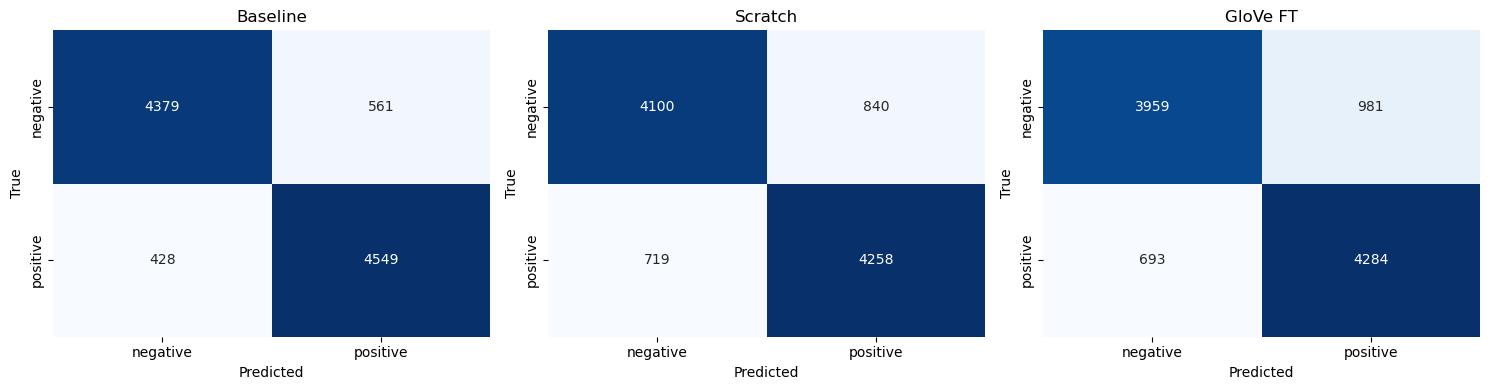

In [ ]:
# Detailed reports + confusion matrices
labels = ['negative', 'positive']
print('=== Baseline TF-IDF+LR ===')
print(classification_report(y_true, y_pred_base, target_names=labels))
print('Confusion matrix:\n', confusion_matrix(y_true, y_pred_base))
print('\n=== Scratch CNN-BiLSTM ===')
print(classification_report(y_true, y_pred_scratch, target_names=labels))
print('Confusion matrix:\n', confusion_matrix(y_true, y_pred_scratch))
print('\n=== GloVe CNN-BiLSTM (fine-tuned) ===')
print(classification_report(y_true, y_pred_glove, target_names=labels))
print('Confusion matrix:\n', confusion_matrix(y_true, y_pred_glove))

# Optional: visualize confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name, pred in [
    (axes[0], 'Baseline', y_pred_base),
    (axes[1], 'Scratch', y_pred_scratch),
    (axes[2], 'GloVe FT', y_pred_glove),
]:
    cm = confusion_matrix(y_true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
plt.tight_layout()
plt.show()


In [ ]:
# Error analysis: inspect some misclassified reviews

def show_misclassified(texts, y_true, y_pred, proba=None, n=10):
    df_err = pd.DataFrame({
        'review': pd.Series(list(texts)).reset_index(drop=True),
        'y_true': pd.Series(y_true).reset_index(drop=True),
        'y_pred': pd.Series(y_pred).reset_index(drop=True),
    })
    if proba is not None:
        # probability of positive class (class 1)
        df_err['p_pos'] = pd.Series(proba[:, 1]).reset_index(drop=True)

    mis = df_err[df_err['y_true'] != df_err['y_pred']].copy()
    print(f"Misclassified: {len(mis)} / {len(df_err)}")

    if len(mis) == 0:
        return

    # Show the most confident mistakes first (if probabilities exist)
    if 'p_pos' in mis.columns:
        mis['conf'] = np.where(mis['y_pred'] == 1, mis['p_pos'], 1 - mis['p_pos'])
        mis = mis.sort_values('conf', ascending=False)

    for i, row in mis.head(n).iterrows():
        snippet = row['review'][:300].replace('\n', ' ')
        print('-' * 90)
        print(f"true={row['y_true']} pred={row['y_pred']}" + (f" p_pos={row.get('p_pos', None):.3f}" if 'p_pos' in row else ''))
        print(snippet)

print('Scratch model misclassifications:')
show_misclassified(X_test_text, y_true, y_pred_scratch, proba_scratch, n=10)
print('\nGloVe fine-tuned model misclassifications:')
show_misclassified(X_test_text, y_true, y_pred_glove, proba_glove, n=10)


Scratch model misclassifications:
Misclassified: 1559 / 9917
------------------------------------------------------------------------------------------
true=0 pred=1 p_pos=1.000
anita and me seems to be little more than an excuse for meera syal the author of the novel and screenplay to air her prejudices grievances and general antipathy towards the english the general sentiment of indian superiority over the english in this film is foulthe english people in this film are po
------------------------------------------------------------------------------------------
true=0 pred=1 p_pos=1.000
rob schneider is a famous comedian cause of his movements facials and performances of not humans this time he is the animal marvin is a loser who is trying to be a hero and one day nobody takes a call from a man that gets attacked so marvin has to take this case and save the attacked man but on his 
------------------------------------------------------------------------------------------
true=0 pred=

## Saving Artifacts (Model + Preprocessing)

For deployment and reproducibility, we save:

- Trained Keras models (`.keras`)
- The Keras `Tokenizer`
- The TF‑IDF `vectorizer` + Logistic Regression baseline model
- A small JSON config (`vocab_size`, `max_len`, label mapping)

This guarantees inference uses the **exact same preprocessing** as training.


In [ ]:

import os, json
os.makedirs('artifacts', exist_ok=True)

# Save Keras models
model.save('artifacts/scratch_model.keras')
model_glove.save('artifacts/glove_finetuned_model.keras')

# Save Tokenizer
with open('artifacts/tokenizer.json', 'w', encoding='utf-8') as f:
    f.write(tokenizer.to_json())

# Save baseline vectorizer + classifier
import joblib
joblib.dump(vectorizer, 'artifacts/tfidf_vectorizer.joblib')
joblib.dump(baseline_clf, 'artifacts/tfidf_logreg.joblib')

# Save small config
config = {
    'vocab_size': int(vocab_size),
    'max_len': int(max_len),
    'label_map': {'negative': 0, 'positive': 1},
}
with open('artifacts/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2)

print('Saved artifacts to ./artifacts/')


Saved artifacts to ./artifacts/
